<a href="https://colab.research.google.com/github/emilheroyt/Bachelor-Thesis-Stress-Testing-Robustness-of-SOTA-Point-Trackers/blob/main/AlleDreiCSVs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zelle 1 – Drive mounten + alle drei CSVs laden:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

base = "/content/drive/MyDrive/ba_results/"
df_cotracker = pd.read_csv(base + "cotracker3_all_videos.csv")
df_tapnext = pd.read_csv(base + "tapnext_all_videos.csv")
df_cowtracker = pd.read_csv(base + "cowtracker_all_videos.csv")

df_all = pd.concat([df_cotracker, df_tapnext, df_cowtracker], ignore_index=True)
df_all.to_csv(base + "all_models_combined.csv", index=False)

print(df_all.groupby(["model", "blur"])[["average_jaccard", "occlusion_accuracy", "average_pts_within_thresh"]].mean())

Mounted at /content/drive
                   average_jaccard  occlusion_accuracy  \
model      blur                                          
CoTracker3 medium        46.862323           80.375335   
           none          62.563783           88.130537   
           strong        25.950106           66.902586   
CoWTracker medium        48.242677           88.486367   
           none          56.898783           90.839517   
           strong        33.970111           84.666453   
TapNext    medium        42.324421           77.255704   
           none          66.708108           91.340181   
           strong        19.219172           62.053555   

                   average_pts_within_thresh  
model      blur                               
CoTracker3 medium                  63.598239  
           none                    77.193544  
           strong                  41.592528  
CoWTracker medium                  62.725759  
           none                    71.230006  
      

Zelle 2 – Vergleichsplot für Experiment 1 (AJ über alle drei Modelle):

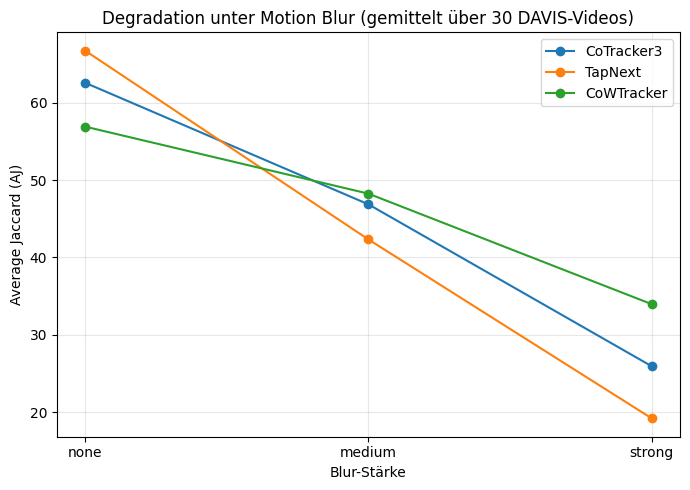

In [ ]:
import matplotlib.pyplot as plt

summary = df_all.groupby(["model", "blur"])["average_jaccard"].mean().reset_index()
blur_order = ["none", "medium", "strong"]

fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["CoTracker3", "TapNext", "CoWTracker"]:
    sub = summary[summary["model"] == model_name].set_index("blur").reindex(blur_order)
    ax.plot(blur_order, sub["average_jaccard"], marker="o", label=model_name)

ax.set_xlabel("Blur-Stärke")
ax.set_ylabel("Average Jaccard (AJ)")
ax.set_title("Degradation unter Motion Blur (gemittelt über 30 DAVIS-Videos)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(base + "experiment1_aj_degradation.png", dpi=150)
plt.show()

Zelle 3 – Dieselbe Art Plot für OA und δ, plus eine kombinierte Tabelle für die Arbeit:

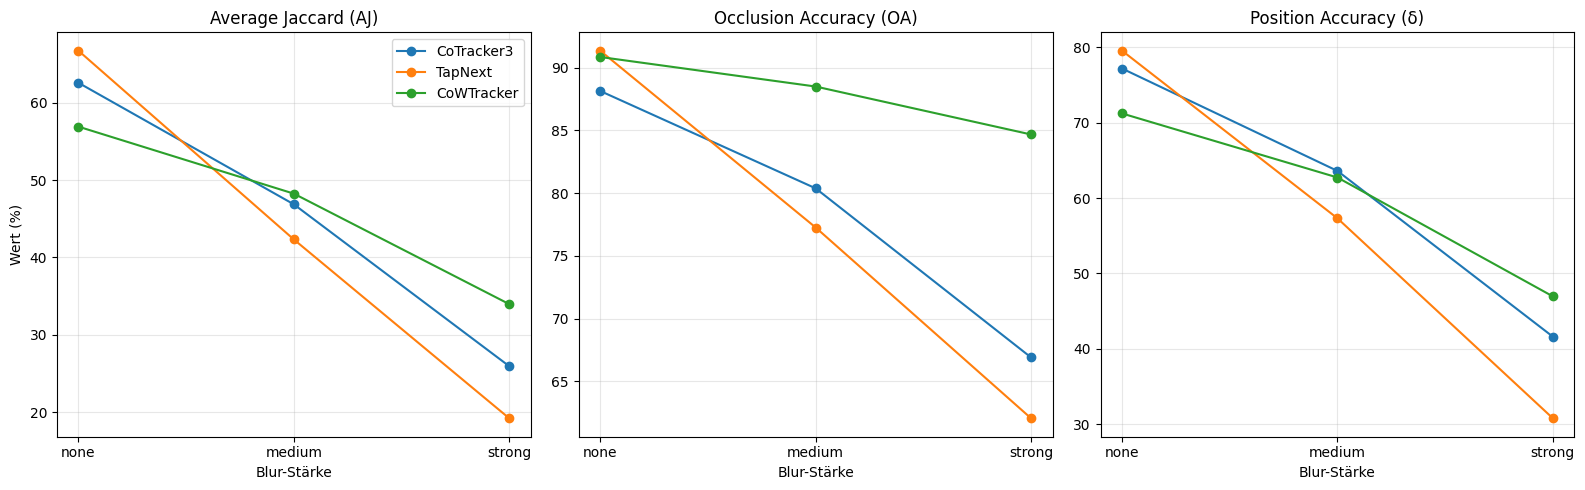

                   average_jaccard  occlusion_accuracy  \
model      blur                                          
CoTracker3 medium             46.9                80.4   
           none               62.6                88.1   
           strong             26.0                66.9   
CoWTracker medium             48.2                88.5   
           none               56.9                90.8   
           strong             34.0                84.7   
TapNext    medium             42.3                77.3   
           none               66.7                91.3   
           strong             19.2                62.1   

                   average_pts_within_thresh  
model      blur                               
CoTracker3 medium                       63.6  
           none                         77.2  
           strong                       41.6  
CoWTracker medium                       62.7  
           none                         71.2  
           strong               

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["average_jaccard", "occlusion_accuracy", "average_pts_within_thresh"]
titles = ["Average Jaccard (AJ)", "Occlusion Accuracy (OA)", "Position Accuracy (δ)"]

for ax, metric, title in zip(axes, metrics, titles):
    summary = df_all.groupby(["model", "blur"])[metric].mean().reset_index()
    for model_name in ["CoTracker3", "TapNext", "CoWTracker"]:
        sub = summary[summary["model"] == model_name].set_index("blur").reindex(blur_order)
        ax.plot(blur_order, sub[metric], marker="o", label=model_name)
    ax.set_title(title)
    ax.set_xlabel("Blur-Stärke")
    ax.grid(alpha=0.3)
axes[0].legend()
axes[0].set_ylabel("Wert (%)")
plt.tight_layout()
plt.savefig(base + "experiment1_all_metrics.png", dpi=150)
plt.show()

# Tabelle zum direkten Einfügen in die Arbeit
final_table = df_all.groupby(["model", "blur"])[metrics].mean().round(1)
print(final_table)
final_table.to_csv(base + "experiment1_summary_table.csv")